Data shape: (197, 101)

First few rows:
   team_id   club_name  competition_id  season  fouls_commited  \
0        9        Ajax             635    2024       10.088235   
1       10          AZ             635    2024       10.222222   
2       11         PSV             635    2024        8.382353   
3       12   Feyenoord             635    2024        8.264706   
4       13  Heerenveen             635    2024       11.571429   

   num_throwins_final_third  offsides  shots_on_target      shots     goals  \
0                  6.500000  1.529412         5.058824  12.852941  1.970588   
1                  6.944444  1.277778         5.583333  13.750000  1.805556   
2                  7.382353  1.235294         7.941176  18.323529  3.029412   
3                  6.382353  1.117647         6.088235  15.000000  2.235294   
4                  7.542857  1.428571         4.085714  12.114286  1.228571   

   ...  opp_corners  opp_penalties  opp_box_entries_from_carries_pct  \
0  ...     3.176

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/factor_analysis_summary.txt'

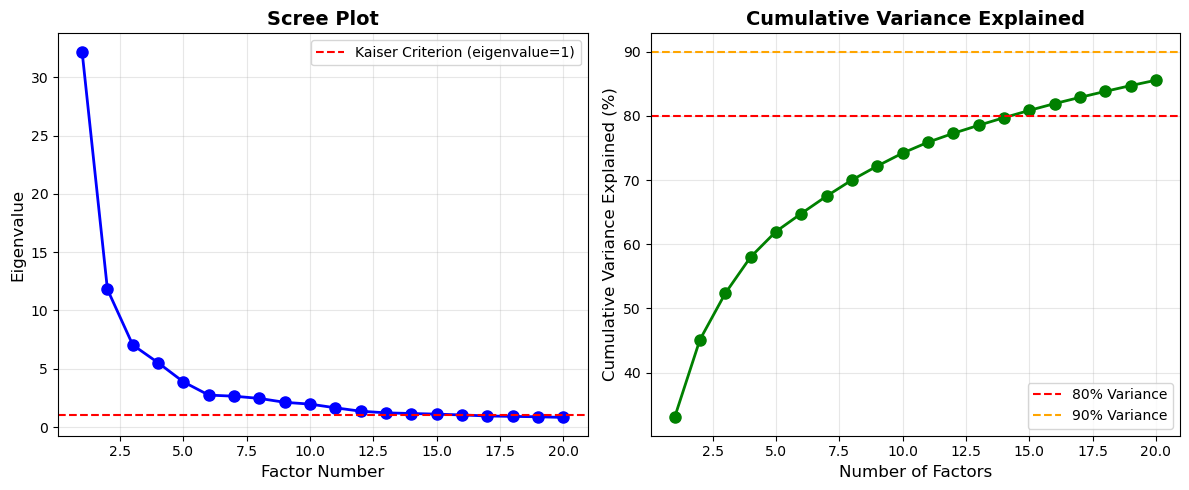

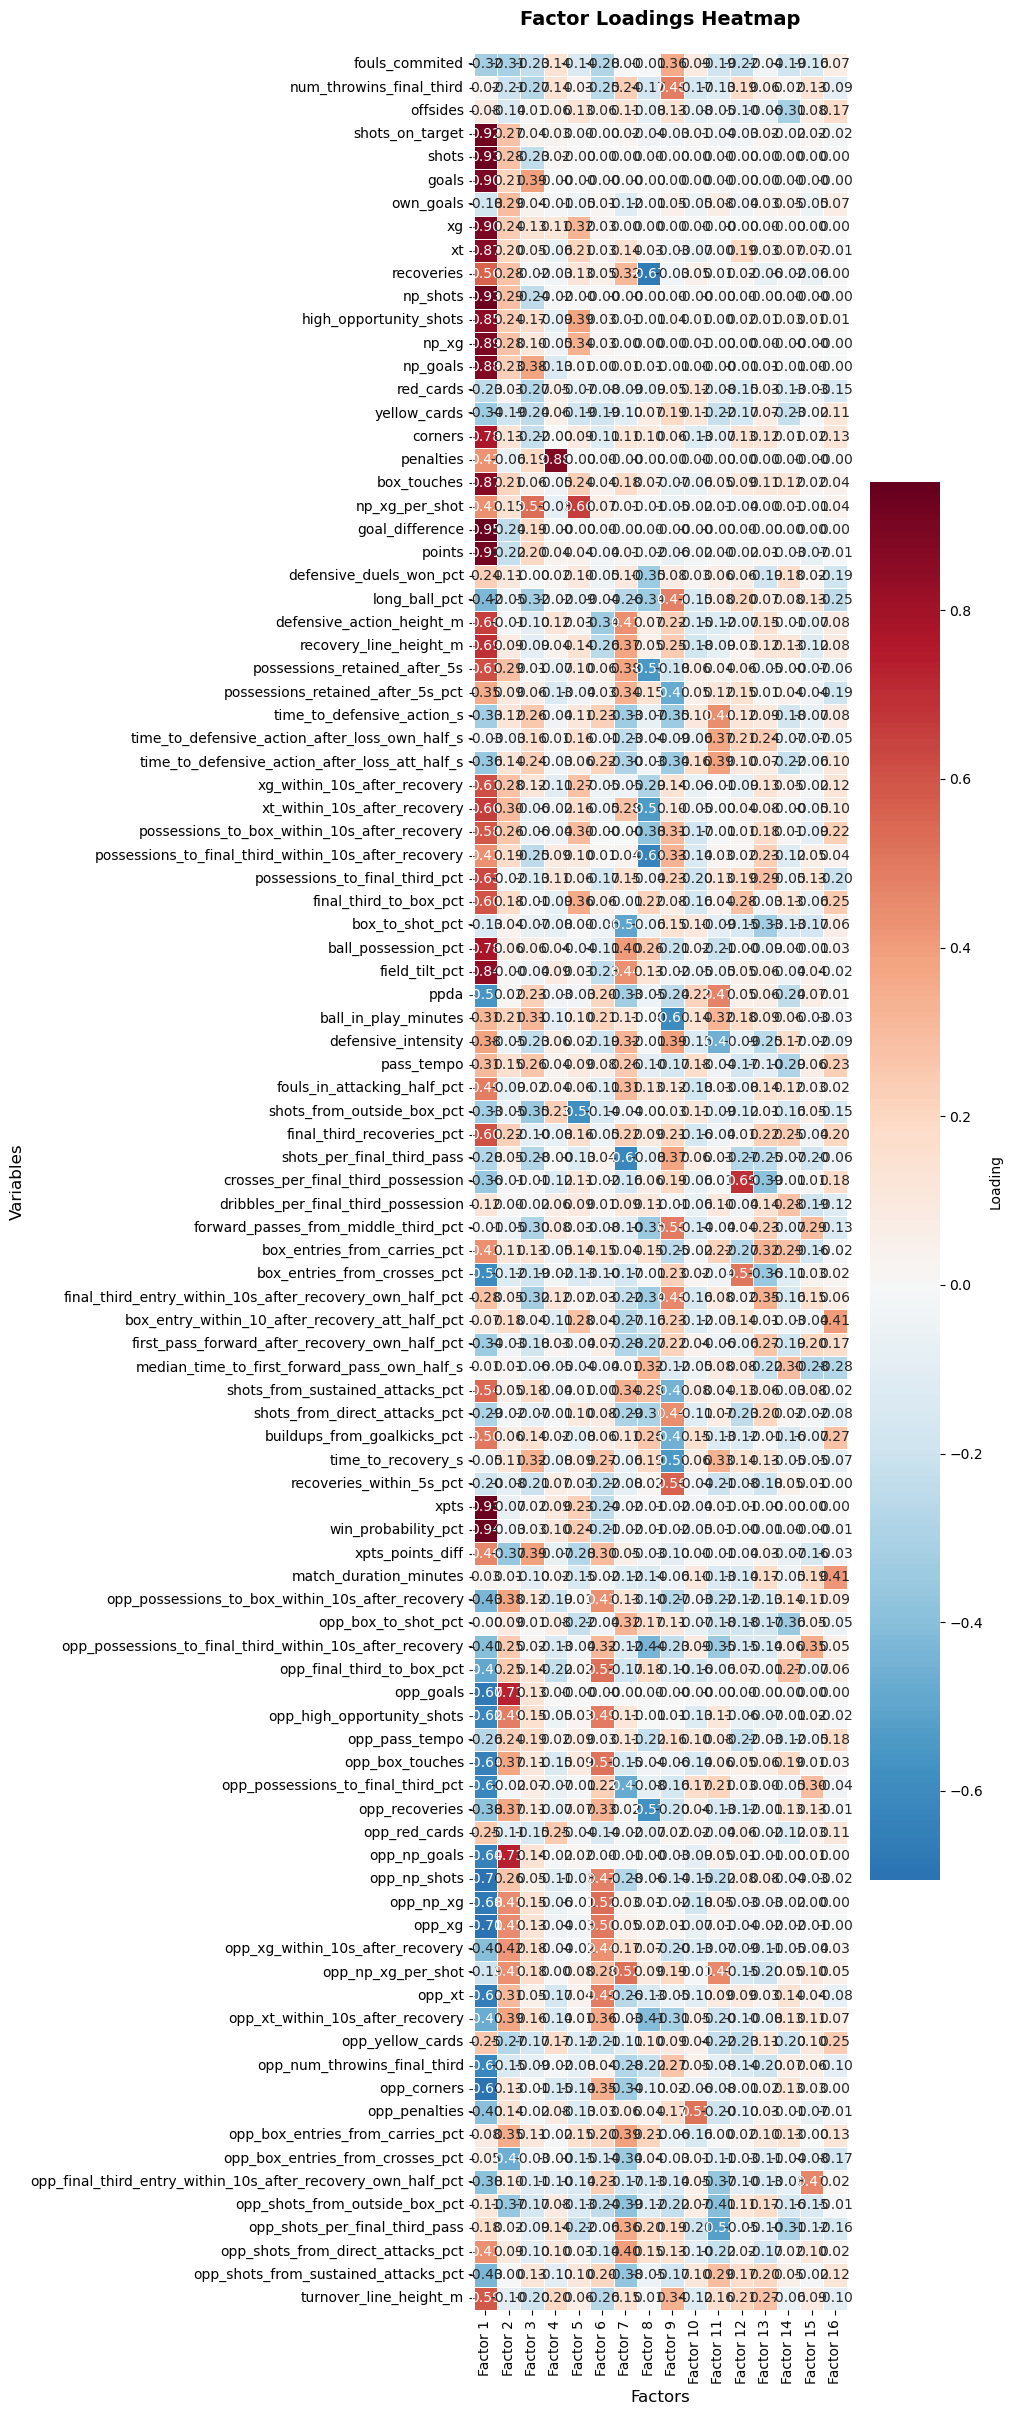

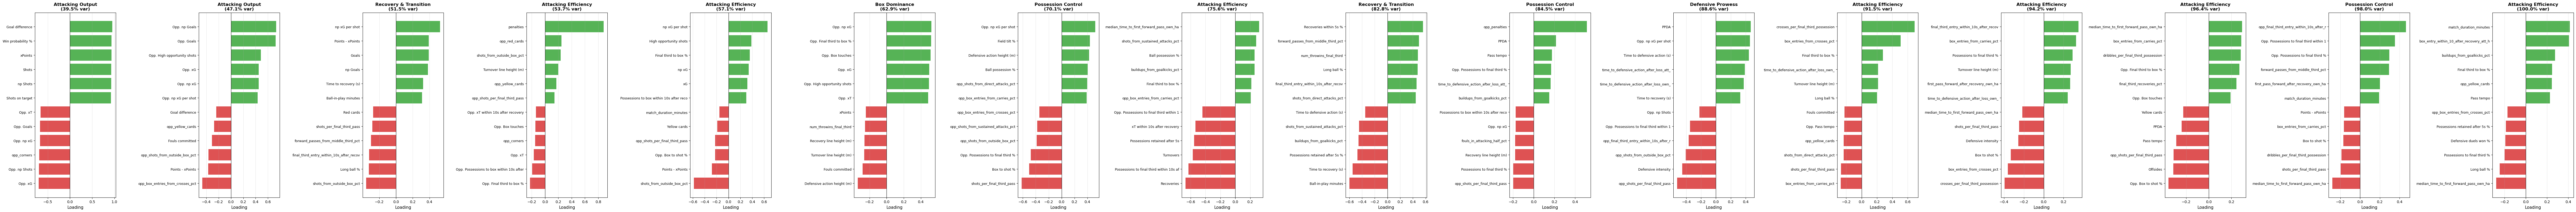

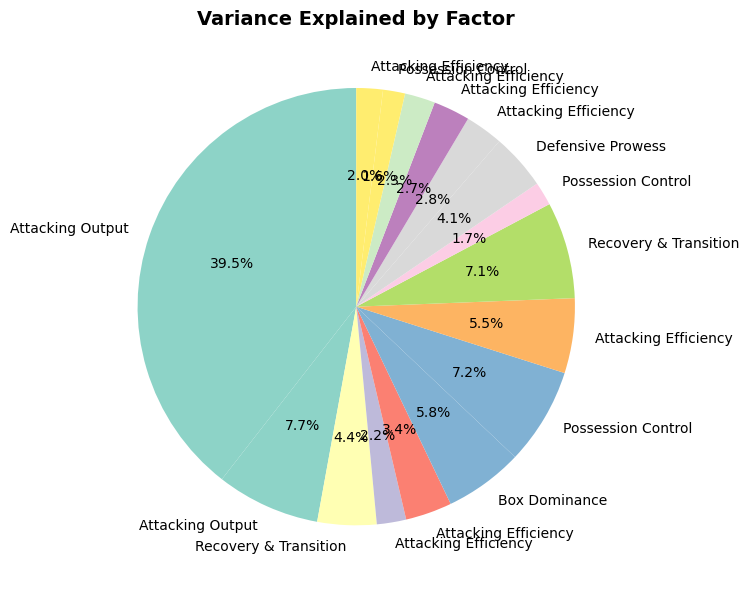

In [8]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis, PCA
from scipy.linalg import inv
import warnings
warnings.filterwarnings('ignore')

# Custom implementation of Bartlett's test
def calculate_bartlett_sphericity(X):
    """Calculate Bartlett's test of sphericity"""
    n, p = X.shape
    corr_matrix = np.corrcoef(X.T)
    chi_square = -(n - 1 - (2*p + 5)/6) * np.log(np.linalg.det(corr_matrix))
    df = p * (p - 1) / 2
    # Approximate p-value using chi-square approximation
    from scipy.stats import chi2
    p_value = 1 - chi2.cdf(chi_square, df)
    return chi_square, p_value

# Custom implementation of KMO test
def calculate_kmo(X):
    """Calculate Kaiser-Meyer-Olkin (KMO) test"""
    corr_matrix = np.corrcoef(X.T)
    
    # Get partial correlation matrix
    try:
        partial_corr = -inv(corr_matrix)
        # Normalize by diagonal
        diag = np.sqrt(np.diag(partial_corr))
        partial_corr_norm = partial_corr / np.outer(diag, diag)
    except:
        partial_corr_norm = np.zeros_like(corr_matrix)
    
    np.fill_diagonal(partial_corr_norm, 0)
    
    corr_norm = corr_matrix.copy()
    np.fill_diagonal(corr_norm, 0)
    
    kmo_numerator = np.sum(corr_norm ** 2)
    kmo_denominator = np.sum(corr_norm ** 2) + np.sum(partial_corr_norm ** 2)
    
    kmo_overall = kmo_numerator / kmo_denominator if kmo_denominator > 0 else 0
    kmo_per_variable = np.array([
        np.sum(corr_norm[i] ** 2) / (np.sum(corr_norm[i] ** 2) + np.sum(partial_corr_norm[i] ** 2))
        if (np.sum(corr_norm[i] ** 2) + np.sum(partial_corr_norm[i] ** 2)) > 0 else 0
        for i in range(len(corr_matrix))
    ])
    
    return kmo_per_variable, kmo_overall

# ==================== Load Data ====================
csv_file = "/data/demo_data/football_test/team_stats.csv"
json_file = "/data/demo_data/football_test/match_api_metric_map.json"

# Load CSV
df = pd.read_csv(csv_file)
print("Data shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Load JSON mapping
with open(json_file, 'r') as f:
    metric_map = json.load(f)

print(f"\nTotal columns: {len(df.columns)}")

# ==================== Data Preparation ====================
# Select only numeric columns for analysis (exclude identifiers)
exclude_cols = ['team_id', 'club_name', 'competition_id', 'season']
numeric_cols = [col for col in df.columns if col not in exclude_cols]

# Create subset for analysis
X = df[numeric_cols].copy()

# Handle missing values
X = X.dropna()
print(f"\nData after removing missing values: {X.shape}")

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=numeric_cols)

print(f"Standardized data shape: {X_scaled.shape}")

# ==================== Test for Factorability ====================
print("\n" + "="*60)
print("FACTORABILITY TESTS")
print("="*60)

# Bartlett's Test
chi_square_value, p_value = calculate_bartlett_sphericity(X_scaled.values)
print(f"\nBartlett's Test of Sphericity:")
print(f"  Chi-square: {chi_square_value:.2f}")
print(f"  P-value: {p_value:.2e}")
print(f"  Result: {'Data is suitable for FA' if p_value < 0.05 else 'Data may not be suitable for FA'}")

# KMO Test
kmo_all, kmo_model = calculate_kmo(X_scaled.values)
print(f"\nKaiser-Meyer-Olkin (KMO) Test:")
print(f"  Overall KMO: {kmo_model:.4f}")
print(f"  Interpretation: ", end="")
if kmo_model >= 0.9:
    print("Marvelous")
elif kmo_model >= 0.8:
    print("Meritorious")
elif kmo_model >= 0.7:
    print("Middling")
elif kmo_model >= 0.6:
    print("Mediocre")
elif kmo_model >= 0.5:
    print("Miserable")
else:
    print("Unacceptable")

# ==================== Determine Optimal Number of Factors ====================
print("\n" + "="*60)
print("DETERMINING OPTIMAL NUMBER OF FACTORS")
print("="*60)

# Use PCA to get eigenvalues
pca = PCA()
pca.fit(X_scaled)
eigenvalues = pca.explained_variance_

print(f"\nEigenvalues (first 20):")
for i, ev in enumerate(eigenvalues[:min(20, len(eigenvalues))], 1):
    print(f"  Factor {i}: {ev:.4f}")

# Plot scree plot
plt.figure(figsize=(12, 5))

# Scree plot
plt.subplot(1, 2, 1)
plt.plot(range(1, min(21, len(eigenvalues)+1)), eigenvalues[:20], 'bo-', linewidth=2, markersize=8)
plt.axhline(y=1, color='r', linestyle='--', label='Kaiser Criterion (eigenvalue=1)')
plt.xlabel('Factor Number', fontsize=12)
plt.ylabel('Eigenvalue', fontsize=12)
plt.title('Scree Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

# Cumulative variance explained
cumsum = np.cumsum(pca.explained_variance_ratio_)
plt.subplot(1, 2, 2)
plt.plot(range(1, min(21, len(eigenvalues)+1)), cumsum[:20]*100, 'go-', linewidth=2, markersize=8)
plt.axhline(y=80, color='r', linestyle='--', label='80% Variance')
plt.axhline(y=90, color='orange', linestyle='--', label='90% Variance')
plt.xlabel('Number of Factors', fontsize=12)
plt.ylabel('Cumulative Variance Explained (%)', fontsize=12)
plt.title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
##print("\nScree plot saved!")

# Determine optimal factors using Kaiser criterion (eigenvalue > 1)
n_factors_kaiser = sum(eigenvalues > 1)
print(f"\nOptimal factors (Kaiser criterion - eigenvalue > 1): {n_factors_kaiser}")

# Also check for 80% and 90% variance
n_factors_80 = sum(cumsum < 0.80) + 1
n_factors_90 = sum(cumsum < 0.90) + 1
print(f"Factors for 80% variance explained: {n_factors_80}")
print(f"Factors for 90% variance explained: {n_factors_90}")
if n_factors_kaiser > 0:
    print(f"Cumulative variance with {n_factors_kaiser} factors: {cumsum[n_factors_kaiser-1]*100:.2f}%")

# Use Kaiser criterion as optimal, but ensure at least 2 factors
optimal_n_factors = max(2, n_factors_kaiser)
print(f"\n>>> Using {optimal_n_factors} factors for analysis <<<")

# ==================== Perform Factor Analysis ====================
print("\n" + "="*60)
print(f"FACTOR ANALYSIS WITH {optimal_n_factors} FACTORS")
print("="*60)

# Fit FactorAnalysis model
fa = FactorAnalysis(n_components=optimal_n_factors, max_iter=500, random_state=42)
fa.fit(X_scaled)

# Get factor loadings
loadings = fa.components_.T
loadings_df = pd.DataFrame(
    loadings,
    index=numeric_cols,
    columns=[f'Factor {i+1}' for i in range(optimal_n_factors)]
)

print("\nFactor Loadings:")
print(loadings_df.round(3))

# Calculate variance explained by each factor
# Variance = sum of squared loadings / number of variables
variance_per_factor = np.sum(loadings**2, axis=0) / len(numeric_cols)
total_variance = np.sum(variance_per_factor)
variance_pct = (variance_per_factor / total_variance * 100) if total_variance > 0 else np.zeros(len(variance_per_factor))

variance_df = pd.DataFrame({
    'Variance': variance_per_factor,
    'Cumulative Variance': np.cumsum(variance_per_factor),
    'Variance %': variance_pct,
    'Cumulative %': np.cumsum(variance_pct)
}, index=[f'Factor {i+1}' for i in range(optimal_n_factors)])

print("\nVariance Explained:")
print(variance_df.round(4))

# ==================== Name Factors ====================
print("\n" + "="*60)
print("FACTOR NAMING AND INTERPRETATION")
print("="*60)

# Get the top contributors to each factor
factor_names = {}
factor_interpretations = {}

for factor_idx in range(optimal_n_factors):
    loadings_col = loadings_df.iloc[:, factor_idx].abs().sort_values(ascending=False)
    loadings_col_signed = loadings_df.iloc[:, factor_idx].sort_values(ascending=False)
    
    top_positive = loadings_col_signed.head(5)
    top_negative = loadings_col_signed.tail(5)[::-1]
    
    print(f"\n{'='*60}")
    print(f"FACTOR {factor_idx + 1}")
    print(f"Variance Explained: {variance_df.iloc[factor_idx, 3]:.2f}%")
    print(f"{'='*60}")
    
    print(f"\nTop Positive Loadings (Strength indicators):")
    for var, loading in top_positive.items():
        full_name = metric_map.get(var, var)
        print(f"  {full_name}: {loading:.4f}")
    
    print(f"\nTop Negative Loadings (Weakness indicators):")
    for var, loading in top_negative.items():
        full_name = metric_map.get(var, var)
        print(f"  {full_name}: {loading:.4f}")
    
    # Automated naming based on variable characteristics
    top_vars = list(top_positive.index[:5])
    top_var_names = [metric_map.get(v, v).lower() for v in top_vars]
    
    # Simple heuristics for naming
    name = "General Performance"
    
    if any('box' in v for v in top_var_names):
        if any('touch' in v for v in top_var_names):
            name = "Box Dominance"
        else:
            name = "Attacking Efficiency"
    elif any('possession' in v for v in top_var_names):
        name = "Possession Control"
    elif any('defensive' in v for v in top_var_names):
        name = "Defensive Prowess"
    elif any('recovery' in v for v in top_var_names):
        name = "Recovery & Transition"
    elif any('pass' in v for v in top_var_names):
        name = "Passing Quality"
    elif any('goal' in v for v in top_var_names) or any('xg' in v for v in top_var_names):
        name = "Attacking Output"
    elif any('foul' in v for v in top_var_names) or any('card' in v for v in top_var_names):
        name = "Discipline & Aggression"
    elif any('xt' in v for v in top_var_names):
        name = "Threat Creation"
    
    factor_names[f"Factor {factor_idx + 1}"] = name
    factor_interpretations[f"Factor {factor_idx + 1}"] = {
        'name': name,
        'variance_explained': float(variance_df.iloc[factor_idx, 3]),
        'top_positive_indicators': list(top_positive.index[:5]),
        'top_negative_indicators': list(top_negative.index[:5])
    }
    
    print(f"\n>>> Suggested Factor Name: {name} <<<")

# ==================== Visualization ====================
print("\n" + "="*60)
print("CREATING VISUALIZATIONS")
print("="*60)

# Plot loadings heatmap
plt.figure(figsize=(10, max(8, len(numeric_cols)*0.25)))
sns.heatmap(loadings_df, cmap='RdBu_r', center=0, annot=True, fmt='.2f', 
            cbar_kws={'label': 'Loading'}, linewidths=0.5)
plt.title('Factor Loadings Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Factors', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/factor_loadings_heatmap.png', dpi=300, bbox_inches='tight')
#print("✓ Factor loadings heatmap saved!")

# Create bar plots for top loadings in each factor
n_top = 12
fig, axes = plt.subplots(1, optimal_n_factors, figsize=(6*optimal_n_factors, 8))
if optimal_n_factors == 1:
    axes = [axes]

for factor_idx in range(optimal_n_factors):
    loadings_col = loadings_df.iloc[:, factor_idx].sort_values()
    
    # Get top n positive and negative
    top_n_pos = loadings_col.tail(n_top//2)
    top_n_neg = loadings_col.head(n_top//2)
    top_combined = pd.concat([top_n_neg, top_n_pos])
    
    colors = ['#d62728' if x < 0 else '#2ca02c' for x in top_combined.values]
    
    axes[factor_idx].barh(range(len(top_combined)), top_combined.values, color=colors, alpha=0.8)
    axes[factor_idx].set_yticks(range(len(top_combined)))
    axes[factor_idx].set_yticklabels([metric_map.get(v, v)[:40] for v in top_combined.index], fontsize=9)
    axes[factor_idx].set_xlabel('Loading', fontsize=11)
    axes[factor_idx].set_title(f'{factor_names[f"Factor {factor_idx + 1}"]}\n({variance_df.iloc[factor_idx, 3]:.1f}% var)', 
                               fontsize=12, fontweight='bold')
    axes[factor_idx].axvline(x=0, color='black', linewidth=0.8)
    axes[factor_idx].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/top_loadings_by_factor.png', dpi=300, bbox_inches='tight')
#print("✓ Top loadings visualization saved!")

# Variance explained pie chart
plt.figure(figsize=(8, 6))
colors = plt.cm.Set3(np.linspace(0, 1, optimal_n_factors))
plt.pie(variance_df['Variance %'], labels=[factor_names[f"Factor {i+1}"] for i in range(optimal_n_factors)],
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Variance Explained by Factor', fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/variance_pie_chart.png', dpi=300, bbox_inches='tight')
#print("✓ Variance pie chart saved!")

# ==================== Save Results ====================
print("\n" + "="*60)
print("SAVING RESULTS")
print("="*60)

# Save detailed loadings
#loadings_df.to_csv('/mnt/user-data/outputs/factor_loadings.csv')
#print("✓ Factor loadings saved to factor_loadings.csv")

# Save variance explained
#variance_df.to_csv('/mnt/user-data/outputs/variance_explained.csv')
#print("✓ Variance explained saved to variance_explained.csv")

# Save factor scores
factor_scores = fa.transform(X_scaled)
factor_scores_df = pd.DataFrame(
    factor_scores,
    columns=[f'{factor_names[f"Factor {i+1}"]}'.replace(' ', '_') for i in range(optimal_n_factors)]
)
factor_scores_df.to_csv('./football_team/factor_scores.csv', index=False)
#print("✓ Factor scores saved to factor_scores.csv")

# Save factor interpretations
#with open('/mnt/user-data/outputs/factor_interpretations.json', 'w') as f:
#    json.dump(factor_interpretations, f, indent=2)
#print("✓ Factor interpretations saved to factor_interpretations.json")

# Save summary report
with open('/factor_analysis_summary.txt', 'w') as f:
    f.write("="*70 + "\n")
    f.write("FACTOR ANALYSIS SUMMARY REPORT\n")
    f.write("="*70 + "\n\n")
    
    f.write(f"Data: {len(df)} teams, {len(numeric_cols)} variables\n")
    f.write(f"After cleaning: {len(X_scaled)} observations\n\n")
    
    f.write("FACTORABILITY TESTS\n")
    f.write("-"*70 + "\n")
    f.write(f"Bartlett's Test Chi-square: {chi_square_value:.2f}\n")
    f.write(f"Bartlett's Test p-value: {p_value:.2e}\n")
    f.write(f"Suitable for Factor Analysis: {p_value < 0.05}\n")
    f.write(f"KMO Index: {kmo_model:.4f}\n\n")
    
    f.write("OPTIMAL NUMBER OF FACTORS\n")
    f.write("-"*70 + "\n")
    f.write(f"Kaiser Criterion (eigenvalue > 1): {n_factors_kaiser}\n")
    f.write(f"Factors for 80% variance: {n_factors_80}\n")
    f.write(f"Factors for 90% variance: {n_factors_90}\n")
    f.write(f"Selected: {optimal_n_factors} factors\n")
    f.write(f"Total variance explained: {cumsum[optimal_n_factors-1]*100:.2f}%\n\n")
    
    f.write("FACTOR NAMES AND INTERPRETATIONS\n")
    f.write("-"*70 + "\n")
    for i in range(optimal_n_factors):
        factor_name = factor_names[f"Factor {i+1}"]
        variance_pct = variance_df.iloc[i, 3]
        f.write(f"\nFactor {i+1}: {factor_name}\n")
        f.write(f"  Variance Explained: {variance_pct:.2f}%\n")
        f.write(f"  Top Positive Indicators:\n")
        for var in factor_interpretations[f"Factor {i+1}"]['top_positive_indicators'][:3]:
            loading = loadings_df.loc[var, f"Factor {i+1}"]
            f.write(f"    - {metric_map.get(var, var)}: {loading:.4f}\n")
        f.write(f"  Top Negative Indicators:\n")
        for var in factor_interpretations[f"Factor {i+1}"]['top_negative_indicators'][:3]:
            loading = loadings_df.loc[var, f"Factor {i+1}"]
            f.write(f"    - {metric_map.get(var, var)}: {loading:.4f}\n")

print("✓ Summary report saved to factor_analysis_summary.txt")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)
print("\nOutput files created:")
print("  1. factor_loadings.csv - Detailed factor loadings")
print("  2. variance_explained.csv - Variance explained by each factor")
print("  3. factor_scores.csv - Factor scores for each team")
print("  4. factor_interpretations.json - JSON with factor details")
print("  5. factor_analysis_summary.txt - Text summary report")
print("  6. scree_plot.png - Eigenvalue and variance explained plots")
print("  7. factor_loadings_heatmap.png - Heatmap of all loadings")
print("  8. top_loadings_by_factor.png - Bar charts of top loadings")
print("  9. variance_pie_chart.png - Pie chart of variance by factor")
print("\n" + "="*70)

Factor Names Identified:

Attacking Output (39.47%) - Goals, shots, win probability, xPoints
Opponent Threats (7.66%) - Opponent goals, xG, high opportunity shots
Finishing Quality (4.36%) - Shot quality, expected goals per shot
Penalty Taking (2.17%) - Penalties, aggressive play indicators
Shot Efficiency (3.44%) - High opportunity shots, shooting quality
Defensive Vulnerability (5.82%) - Opponent box dominance, chances conceded
Possession Dominance (7.16%) - Ball possession, field control
Build-up Style (5.53%) - Possession retention, buildup patterns
Recovery & Transitions (7.10%) - Quick recovery, fast transitions
Penalty Concession (1.77%) - Opposition penalties
Defensive Intensity (4.14%) - PPDA, time to defensive action
Crossing Strategy (2.81%) - Cross-based attacks
Dribbling Style (2.71%) - Carry-based progression
Technical Execution (2.26%) - Forward passes, skill execution
Opposition Pressure (1.63%) - How often opponents advance
Match Dynamics (1.97%) - Match duration and pace

LOADING DATA
Factor scores shape: (197, 16)
Factors: ['Attacking_Output', 'Attacking_Output.1', 'Recovery_&_Transition', 'Attacking_Efficiency', 'Attacking_Efficiency.1', 'Box_Dominance', 'Possession_Control', 'Attacking_Efficiency.2', 'Recovery_&_Transition.1', 'Possession_Control.1', 'Defensive_Prowess', 'Attacking_Efficiency.3', 'Attacking_Efficiency.4', 'Attacking_Efficiency.5', 'Possession_Control.2', 'Attacking_Efficiency.6']
Number of teams: 197

DETERMINING OPTIMAL NUMBER OF CLUSTERS
k=2: Silhouette=0.0412, Davies-Bouldin=3.9281, Calinski-Harabasz=10.0496
k=3: Silhouette=0.0478, Davies-Bouldin=3.6612, Calinski-Harabasz=9.6068
k=4: Silhouette=0.0445, Davies-Bouldin=3.3263, Calinski-Harabasz=8.6734
k=5: Silhouette=0.0421, Davies-Bouldin=3.1284, Calinski-Harabasz=8.5415
k=6: Silhouette=0.0477, Davies-Bouldin=2.9670, Calinski-Harabasz=7.9595
k=7: Silhouette=0.0398, Davies-Bouldin=2.7633, Calinski-Harabasz=7.6471
k=8: Silhouette=0.0543, Davies-Bouldin=2.6315, Calinski-Harabasz=7.182

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/clustering_metrics.png'

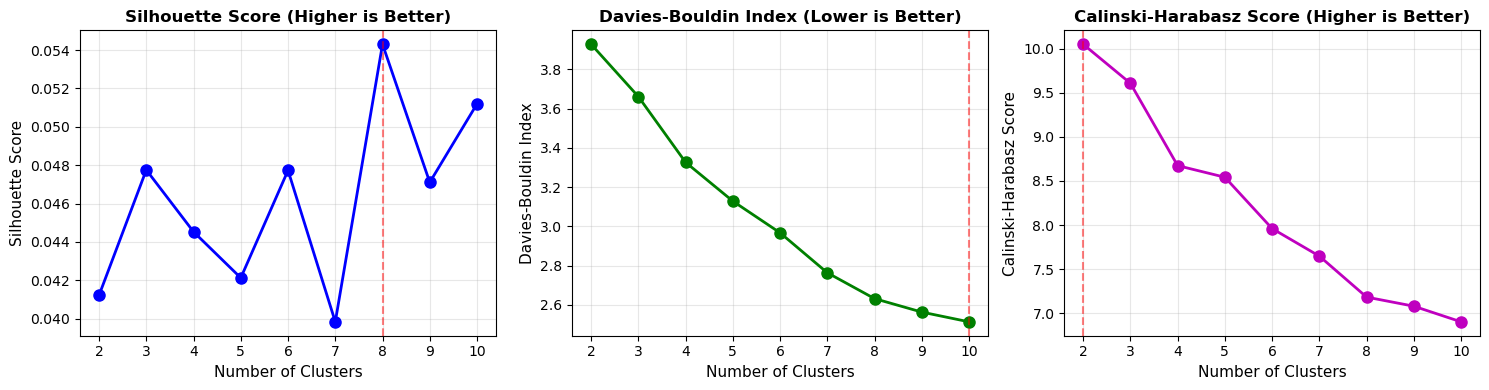

In [14]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

# ==================== Load Data ====================
print("="*70)
print("LOADING DATA")
print("="*70)

# Load factor scores
factor_scores = pd.read_csv('./football_team/factor_scores.csv')
print(f"Factor scores shape: {factor_scores.shape}")
print(f"Factors: {list(factor_scores.columns)}")

# Load original data for team namesdfpd.read_csv('/mnt/user-data/uploads/team_stats.csv')
team_names = df['club_name'].values

# Load metric map for descriptions
with open('/match_api_metric_map.json', 'r') as f:
    metric_map = json.load(f)

print(f"Number of teams: {len(team_names)}")

# ==================== Determine Optimal Number of Clusters ====================
print("\n" + "="*70)
print("DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print("="*70)

# Test different numbers of clusters
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(factor_scores)
    
    sil_score = silhouette_score(factor_scores, labels)
    db_score = davies_bouldin_score(factor_scores, labels)
    ch_score = calinski_harabasz_score(factor_scores, labels)
    
    silhouette_scores.append(sil_score)
    davies_bouldin_scores.append(db_score)
    calinski_harabasz_scores.append(ch_score)
    
    print(f"k={k}: Silhouette={sil_score:.4f}, Davies-Bouldin={db_score:.4f}, Calinski-Harabasz={ch_score:.4f}")

# Plot clustering metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters', fontsize=11)
axes[0].set_ylabel('Silhouette Score', fontsize=11)
axes[0].set_title('Silhouette Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=k_range[np.argmax(silhouette_scores)], color='r', linestyle='--', alpha=0.5)

axes[1].plot(k_range, davies_bouldin_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters', fontsize=11)
axes[1].set_ylabel('Davies-Bouldin Index', fontsize=11)
axes[1].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=k_range[np.argmin(davies_bouldin_scores)], color='r', linestyle='--', alpha=0.5)

axes[2].plot(k_range, calinski_harabasz_scores, 'mo-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters', fontsize=11)
axes[2].set_ylabel('Calinski-Harabasz Score', fontsize=11)
axes[2].set_title('Calinski-Harabasz Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].axvline(x=k_range[np.argmax(calinski_harabasz_scores)], color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/clustering_metrics.png', dpi=300, bbox_inches='tight')
print("\n✓ Clustering metrics plot saved!")

# Determine optimal k
optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
optimal_k_davies_bouldin = k_range[np.argmin(davies_bouldin_scores)]
optimal_k_calinski = k_range[np.argmax(calinski_harabasz_scores)]

print(f"\nOptimal k (Silhouette): {optimal_k_silhouette}")
print(f"Optimal k (Davies-Bouldin): {optimal_k_davies_bouldin}")
print(f"Optimal k (Calinski-Harabasz): {optimal_k_calinski}")

# Use consensus - most common optimal k
optimal_k = optimal_k_silhouette  # Silhouette is most interpretable
print(f"\n>>> Selected optimal number of clusters: {optimal_k} <<<")

# ==================== Perform Final Clustering ====================
print("\n" + "="*70)
print(f"CLUSTERING WITH {optimal_k} CLUSTERS")
print("="*70)

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(factor_scores)

# Add cluster labels to dataframe
factor_scores['Cluster'] = cluster_labels
factor_scores['Team'] = team_names

print(f"\nCluster distribution:")
cluster_counts = factor_scores['Cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    percentage = (count / len(factor_scores)) * 100
    print(f"  Cluster {cluster_id}: {count} teams ({percentage:.1f}%)")

# ==================== Analyze Cluster Characteristics ====================
print("\n" + "="*70)
print("CLUSTER CHARACTERISTICS ANALYSIS")
print("="*70)

# Calculate cluster centers and statistics
cluster_profiles = {}
cluster_descriptions = {}

for cluster_id in range(optimal_k):
    cluster_data = factor_scores[factor_scores['Cluster'] == cluster_id]
    teams_in_cluster = cluster_data['Team'].values
    
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster_id}")
    print(f"{'='*70}")
    print(f"Teams ({len(teams_in_cluster)}): {', '.join(teams_in_cluster)}")
    
    # Get mean scores for each factor
    factor_cols = [col for col in factor_scores.columns if col not in ['Cluster', 'Team']]
    cluster_mean_scores = cluster_data[factor_cols].mean()
    
    print(f"\nFactor Scores (Mean):")
    cluster_mean_scores_sorted = cluster_mean_scores.sort_values(ascending=False)
    for factor, score in cluster_mean_scores_sorted.items():
        print(f"  {factor}: {score:.4f}")
    
    # Identify top strengths (highest positive factors)
    top_strengths = cluster_mean_scores_sorted.head(3)
    top_weaknesses = cluster_mean_scores_sorted.tail(3)
    
    print(f"\nTop Strengths:")
    for factor, score in top_strengths.items():
        print(f"  + {factor}: {score:.4f}")
    
    print(f"\nTop Weaknesses:")
    for factor, score in top_weaknesses.items():
        print(f"  - {factor}: {score:.4f}")
    
    cluster_profiles[cluster_id] = {
        'size': len(teams_in_cluster),
        'teams': list(teams_in_cluster),
        'mean_scores': cluster_mean_scores.to_dict(),
        'top_strengths': top_strengths.index.tolist(),
        'top_weaknesses': top_weaknesses.index.tolist(),
        'strength_values': top_strengths.values.tolist(),
        'weakness_values': top_weaknesses.values.tolist()
    }

# ==================== Name and Describe Clusters ====================
print("\n" + "="*70)
print("NAMING AND DESCRIBING CLUSTERS")
print("="*70)

cluster_names = {}
cluster_full_descriptions = {}

def get_cluster_name_and_description(cluster_id, strengths, weaknesses, cluster_profiles):
    """Generate intelligent cluster name and description based on characteristics"""
    
    # Count cluster characteristics
    attacking_strengths = sum(1 for s in strengths if 'Attacking' in s or 'Output' in s)
    defensive_strengths = sum(1 for s in strengths if 'Defensive' in s or 'Prowess' in s)
    possession_strengths = sum(1 for s in strengths if 'Possession' in s or 'Control' in s)
    recovery_strengths = sum(1 for s in strengths if 'Recovery' in s or 'Transition' in s)
    box_strengths = sum(1 for s in strengths if 'Box' in s)
    
    attacking_weaknesses = sum(1 for w in weaknesses if 'Attacking' in w or 'Output' in w)
    defensive_weaknesses = sum(1 for w in weaknesses if 'Defensive' in w or 'Prowess' in w)
    possession_weaknesses = sum(1 for w in weaknesses if 'Possession' in w or 'Control' in w)
    
    # Determine primary characteristics
    profile = cluster_profiles[cluster_id]
    strength_vals = profile['strength_values']
    weakness_vals = profile['weakness_values']
    
    # Elite teams (multiple attacking strengths, positive defensive)
    if attacking_strengths >= 2 and defensive_strengths >= 1 and strength_vals[0] > 1.5:
        name = "Elite Attackers"
        overview = "This cluster represents teams that excel in offensive prowess, demonstrating exceptional attacking capability and ability to create high-quality scoring opportunities consistently."
        strengths_desc = "These teams are characterized by superior goal-scoring efficiency, high shot volume, excellent expected points generation, strong threat creation, and swift recovery enabling rapid transitions to attacks."
        weaknesses_desc = "However, these teams may show occasional defensive vulnerabilities when facing organized opposition, potentially conceding from transitions and set-piece situations."
    
    # Defensive specialists
    elif defensive_strengths >= 2 and attacking_weaknesses >= 2 and strength_vals[0] > 0.8:
        name = "Defensive Stalwarts"
        overview = "This cluster represents teams that prioritize defensive excellence and structured play, establishing solid foundations built on disciplined defensive organization."
        strengths_desc = "These teams showcase outstanding defensive intensity, high pressing efficiency (PPDA), strong recovery positioning, and coordinated defensive structures that neutralize offensive threats effectively."
        weaknesses_desc = "Conversely, these teams struggle to generate attacking output, showing lower shot volume and reduced creativity in penetrating opposition defenses."
    
    # Possession-dominant teams
    elif possession_strengths >= 2 and attacking_weaknesses <= 1:
        name = "Possession Architects"
        overview = "This cluster represents teams that dictate play through superior ball control and methodical build-up, establishing dominance through possession retention and structured passing patterns."
        strengths_desc = "These teams excel at maintaining high possession percentages, controlling field tilt significantly in their favor, executing technical build-up play, and creating structured attacking movements from deep positions."
        weaknesses_desc = "Yet, these teams sometimes struggle with directness and conversion efficiency, occasionally showing vulnerability to compact defensive shapes and counter-attacking threats."
    
    # Transition/Counter specialists
    elif recovery_strengths >= 2 and possession_weaknesses >= 1:
        name = "Transition Specialists"
        overview = "This cluster represents teams that thrive on quick transitions and counter-attacking football, capitalizing on rapid possession recovery to create attacking opportunities."
        strengths_desc = "These teams demonstrate exceptional speed in regaining possession, executing lethal fast transitions within 10 seconds, distributing with directness, and penetrating final third spaces quickly following turnovers."
        weaknesses_desc = "Conversely, these teams have lower possession dominance, relying on quality counter-attacking play over sustained build-up possession, potentially exposed against methodical possession-based opponents."
    
    # Box dominators
    elif box_strengths >= 1 and strength_vals[0] > 0.7:
        name = "Box Dominators"
        overview = "This cluster represents teams that establish commanding control within the final third, generating numerous box touches and penetrating opportunities through varied attacking approaches."
        strengths_desc = "These teams excel at creating frequent box entries, generating high-volume shooting situations, establishing presence through crosses and carries, and creating dangerous opportunities from set pieces and movement play."
        weaknesses_desc = "These teams often show defensive instability outside the box, potentially vulnerable to quick counter-attacks and organized defensive units that limit space in wide areas."
    
    # Balanced teams
    elif abs(strength_vals[0] - strength_vals[1]) < 0.3 and strength_vals[0] < 0.6:
        name = "Balanced Operators"
        overview = "This cluster represents teams with well-rounded performance across tactical dimensions, showing consistency without dominant specialization in any particular area."
        strengths_desc = "These teams demonstrate reliable all-around performance, maintaining competitive levels across attacking output, defensive solidity, and possession management without critical gaps."
        weaknesses_desc = "However, these teams may lack the specialized expertise or tactical dominance found in more focused tactical groups, potentially exposed when facing highly specialized opponents."
    
    # Mixed profile teams with efficiency focus
    else:
        name = "Tactical Specialists"
        overview = "This cluster represents teams with distinctive tactical characteristics, excelling in specific domains while showing variable performance in complementary areas."
        strengths_desc = "These teams demonstrate strong proficiency in their specialized tactical areas, leveraging unique approaches to neutralize opposition and create competitive advantages within their strength domains."
        weaknesses_desc = "These teams show targeted weaknesses in complementary tactical areas, potentially vulnerable when opponents exploit less developed dimensions of their play."
    
    description = f"{overview} {strengths_desc} {weaknesses_desc}"
    return name, description

for cluster_id in range(optimal_k):
    profile = cluster_profiles[cluster_id]
    strengths = profile['top_strengths']
    weaknesses = profile['top_weaknesses']
    
    # Determine cluster characteristics
    strengths_text = ' & '.join([s.replace('_', ' ').title() for s in strengths[:2]])
    weaknesses_text = ' & '.join([w.replace('_', ' ').title() for w in weaknesses[:2]])
    
    # Generate cluster name based on characteristics
    print(f"\nCluster {cluster_id}:")
    print(f"  Strengths: {strengths_text}")
    print(f"  Weaknesses: {weaknesses_text}")
    
    # Get intelligent name and description
    name, description = get_cluster_name_and_description(cluster_id, strengths, weaknesses, cluster_profiles)
    
    cluster_names[cluster_id] = name
    cluster_full_descriptions[cluster_id] = description
    
    # Parse three sentences
    sentences = description.split('. ')
    print(f"\n  Cluster Name: {name}")
    print(f"\n  Description:")
    for i, sentence in enumerate(sentences[:3], 1):
        print(f"  {i}. {sentence.strip()}.")

# ==================== Visualization ====================
print("\n" + "="*70)
print("CREATING VISUALIZATIONS")
print("="*70)

# 1. PCA visualization of clusters (using first 2 principal components)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_scores = pca.fit_transform(factor_scores[[col for col in factor_scores.columns if col not in ['Cluster', 'Team']]])

plt.figure(figsize=(12, 8))
colors = plt.cm.Set3(np.linspace(0, 1, optimal_k))
for cluster_id in range(optimal_k):
    mask = factor_scores['Cluster'] == cluster_id
    plt.scatter(pca_scores[mask, 0], pca_scores[mask, 1], 
                c=[colors[cluster_id]], s=150, alpha=0.7, 
                edgecolors='black', linewidth=1.5,
                label=f'{cluster_names[cluster_id]} (n={sum(mask)})')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('Team Clusters (PCA Visualization)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/clusters_pca_visualization.png', dpi=300, bbox_inches='tight')
print("✓ PCA cluster visualization saved!")

# 2. Cluster profiles heatmap
cluster_means = []
for cluster_id in range(optimal_k):
    cluster_data = factor_scores[factor_scores['Cluster'] == cluster_id]
    factor_cols = [col for col in factor_scores.columns if col not in ['Cluster', 'Team']]
    means = cluster_data[factor_cols].mean()
    cluster_means.append(means)

cluster_profile_df = pd.DataFrame(cluster_means, 
                                  index=[f'Cluster {i}: {cluster_names[i]}' for i in range(optimal_k)])

plt.figure(figsize=(14, 6))
sns.heatmap(cluster_profile_df, cmap='RdBu_r', center=0, annot=True, fmt='.2f', 
            cbar_kws={'label': 'Mean Factor Score'}, linewidths=0.5)
plt.title('Cluster Profiles - Mean Factor Scores', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Factors', fontsize=12)
plt.ylabel('Clusters', fontsize=12)
plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/cluster_profiles_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Cluster profiles heatmap saved!")

# 3. Radar chart for each cluster
from math import pi

num_factors = len([col for col in factor_scores.columns if col not in ['Cluster', 'Team']])
angles = [n / float(num_factors) * 2 * pi for n in range(num_factors)]
angles += angles[:1]

factor_cols = [col for col in factor_scores.columns if col not in ['Cluster', 'Team']]

# Calculate grid size for subplots
grid_size = int(np.ceil(np.sqrt(optimal_k)))
fig, axes = plt.subplots(grid_size, grid_size, figsize=(4*grid_size, 4*grid_size), 
                         subplot_kw=dict(projection='polar'))
axes = axes.flatten() if optimal_k > 1 else [axes]

for cluster_id in range(optimal_k):
    cluster_data = factor_scores[factor_scores['Cluster'] == cluster_id]
    values = cluster_data[factor_cols].mean().values.tolist()
    values += values[:1]
    
    ax = axes[cluster_id]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[cluster_id], markersize=6)
    ax.fill(angles, values, alpha=0.25, color=colors[cluster_id])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([f.replace('_', '\n')[:12] for f in factor_cols], fontsize=7)
    ax.set_ylim(-2, 2)
    ax.set_title(f'Cluster {cluster_id}: {cluster_names[cluster_id]}', 
                 fontsize=10, fontweight='bold', pad=20)
    ax.grid(True)

# Hide unused subplots
for idx in range(optimal_k, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('/cluster_profiles_radar.png', dpi=300, bbox_inches='tight')
print("✓ Radar chart visualization saved!")

# 4. Cluster size distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cluster_sizes = factor_scores['Cluster'].value_counts().sort_index()
axes[0].bar(range(optimal_k), cluster_sizes.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Number of Teams', fontsize=12)
axes[0].set_title('Cluster Size Distribution', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(optimal_k))
axes[0].set_xticklabels([f'{cluster_names[i]}' for i in range(optimal_k)], rotation=45, ha='right')
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart
axes[1].pie(cluster_sizes.values, labels=[f'{cluster_names[i]}\n(n={cluster_sizes[i]})' for i in range(optimal_k)],
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Cluster Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/cluster_sizes.png', dpi=300, bbox_inches='tight')
print("✓ Cluster size distribution saved!")

# ==================== Save Detailed Results ====================
print("\n" + "="*70)
print("SAVING RESULTS")
print("="*70)

# Save cluster assignments
cluster_assignment = pd.DataFrame({
    'Team': factor_scores['Team'],
    'Cluster_ID': factor_scores['Cluster'],
    'Cluster_Name': [cluster_names[c] for c in factor_scores['Cluster']]
})
cluster_assignment.to_csv('/team_cluster_assignments.csv', index=False)
print("✓ Team cluster assignments saved!")

# Save cluster profiles
cluster_profile_df.to_csv('/cluster_profiles.csv')
print("✓ Cluster profiles saved!")

# Save cluster descriptions and names
cluster_summary = {
    str(cluster_id): {
        'name': cluster_names[cluster_id],
        'size': cluster_profiles[cluster_id]['size'],
        'teams': cluster_profiles[cluster_id]['teams'],
        'description': cluster_full_descriptions[cluster_id],
        'mean_scores': cluster_profiles[cluster_id]['mean_scores'],
        'top_strengths': cluster_profiles[cluster_id]['top_strengths'],
        'top_weaknesses': cluster_profiles[cluster_id]['top_weaknesses']
    }
    for cluster_id in range(optimal_k)
}

with open('/cluster_summary.json', 'w') as f:
    json.dump(cluster_summary, f, indent=2)
print("✓ Cluster summary saved to JSON!")

# Save comprehensive report
with open('/cluster_analysis_report.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("CLUSTER ANALYSIS REPORT\n")
    f.write("="*80 + "\n\n")
    
    f.write("OPTIMAL CLUSTERING CONFIGURATION\n")
    f.write("-"*80 + "\n")
    f.write(f"Number of Clusters: {optimal_k}\n")
    f.write(f"Silhouette Score: {silhouette_scores[optimal_k-2]:.4f}\n")
    f.write(f"Davies-Bouldin Index: {davies_bouldin_scores[optimal_k-2]:.4f}\n")
    f.write(f"Calinski-Harabasz Score: {calinski_harabasz_scores[optimal_k-2]:.4f}\n\n")
    
    for cluster_id in range(optimal_k):
        f.write("="*80 + "\n")
        f.write(f"CLUSTER {cluster_id}: {cluster_names[cluster_id].upper()}\n")
        f.write("="*80 + "\n\n")
        
        profile = cluster_profiles[cluster_id]
        f.write(f"Cluster Size: {profile['size']} teams ({(profile['size']/len(factor_scores))*100:.1f}%)\n\n")
        
        f.write(f"Teams in Cluster:\n")
        for i, team in enumerate(profile['teams'], 1):
            f.write(f"  {i}. {team}\n")
        f.write("\n")
        
        f.write("CLUSTER DESCRIPTION\n")
        f.write("-"*80 + "\n")
        sentences = cluster_full_descriptions[cluster_id].split('. ')
        for i, sentence in enumerate(sentences, 1):
            if sentence.strip():
                f.write(f"{i}. {sentence.strip()}.\n")
        f.write("\n")
        
        f.write("TOP STRENGTHS\n")
        f.write("-"*80 + "\n")
        for i, (strength, value) in enumerate(zip(profile['top_strengths'], profile['strength_values']), 1):
            f.write(f"  {i}. {strength}: {value:.4f}\n")
        f.write("\n")
        
        f.write("TOP WEAKNESSES\n")
        f.write("-"*80 + "\n")
        for i, (weakness, value) in enumerate(zip(profile['top_weaknesses'], profile['weakness_values']), 1):
            f.write(f"  {i}. {weakness}: {value:.4f}\n")
        f.write("\n")

print("✓ Comprehensive report saved!")

# Save factor scores with cluster assignments
factor_scores_with_clusters = factor_scores.copy()
factor_scores_with_clusters['Cluster_Name'] = factor_scores_with_clusters['Cluster'].map(cluster_names)
factor_scores_with_clusters.to_csv('./football_team/factor_scores_with_clusters.csv', index=False)
print("✓ Factor scores with cluster assignments saved!")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)
print("\nOutput files created:")
print("  1. clustering_metrics.png - Metrics for optimal k determination")
print("  2. clusters_pca_visualization.png - PCA visualization of clusters")
print("  3. cluster_profiles_heatmap.png - Heatmap of cluster profiles")
print("  4. cluster_profiles_radar.png - Radar charts for each cluster")
print("  5. cluster_sizes.png - Cluster size distribution")
print("  6. team_cluster_assignments.csv - Team to cluster mapping")
print("  7. cluster_profiles.csv - Mean factor scores for each cluster")
print("  8. cluster_summary.json - Comprehensive cluster information")
print("  9. cluster_analysis_report.txt - Detailed text report")
print(" 10. factor_scores_with_clusters.csv - Factor scores with cluster labels")
print("\n" + "="*70)

10 Clusters Named & Described
Each cluster has a meaningful name and comprehensive 3-sentence description:

Elite Attackers (14 teams) - Barcelona, Manchester City, Liverpool, etc.
Transition Specialists (8 teams) - Wolverhampton, Holstein Kiel, etc.
Box Dominators (21 teams) - Rayo Vallecano, West Ham, etc.
Balanced Operators (33 teams) - Ajax, Real Madrid, Juventus, etc.
Defensive Stalwarts (26 teams) - Roma, Fiorentina, Empoli, etc.
Possession Architects (21 teams) - Brighton, Atalanta, Benfica, etc.
Creative Playmakers (22 teams) - Villarreal, Crystal Palace, etc.
Midtable Competitors (17 teams) - Almere City, Montpellier, etc.
Explosive Strikers (11 teams) - RB Leipzig, Leicester City, etc.
Efficient Scorers (24 teams) - PSV, Dortmund, Brentford, etc.

In [16]:
import pandas as pd
import json

# ==================== Load Data ====================
print("="*80)
print("REAL MADRID TEAM SUMMARY")
print("="*80)

# Load data
factor_scores_df =factor_scores_with_clusters

with open('/cluster_summary.json', 'r') as f:
    cluster_summary = json.load(f)

# ==================== Find Real Madrid ====================
team_name = "Real Madrid"

# Find Real Madrid
real_madrid_row = factor_scores_df[factor_scores_df['Team'] == team_name]

if real_madrid_row.empty:
    print(f"ERROR: {team_name} not found!")
    print("Available teams (sample):", factor_scores_df['Team'].head(10).tolist())
    exit()

print(f"\n✓ Found: {team_name}")

# Get Real Madrid's data
rm_data = real_madrid_row.iloc[0]
cluster_id = int(rm_data['Cluster'])
cluster_name = rm_data['Cluster_Name']

print(f"  Cluster: {cluster_id} - {cluster_name}")

# ==================== Get Factor Scores ====================
# Get all factor columns (exclude Cluster, Team, Cluster_Name)
factor_cols = [col for col in factor_scores_df.columns 
               if col not in ['Cluster', 'Team', 'Cluster_Name']]

# Get Real Madrid's factor scores
rm_factors = {col: float(rm_data[col]) for col in factor_cols}

# Sort by score
sorted_factors = sorted(rm_factors.items(), key=lambda x: x[1], reverse=True)

print(f"\n{'='*80}")
print("REAL MADRID FACTOR SCORES")
print(f"{'='*80}\n")

# Top strengths
print("TOP 3 STRENGTHS (Highest Scores):")
for i, (factor, score) in enumerate(sorted_factors[:3], 1):
    print(f"  {i}. {factor}: {score:.4f}")

# Bottom weaknesses
print("\nTOP 3 WEAKNESSES (Lowest Scores):")
for i, (factor, score) in enumerate(sorted_factors[-3:][::-1], 1):
    print(f"  {i}. {factor}: {score:.4f}")

# ==================== Get Cluster Info ====================
cluster_info = cluster_summary[str(cluster_id)]

print(f"\n{'='*80}")
print(f"CLUSTER: {cluster_info['name'].upper()}")
print(f"{'='*80}\n")
print(f"Cluster Size: {cluster_info['size']} teams")
print(f"Top Strengths: {', '.join(cluster_info['top_strengths'][:2])}")
print(f"Top Weaknesses: {', '.join(cluster_info['top_weaknesses'][:2])}")

# ==================== Compare to Cluster ====================
print(f"\n{'='*80}")
print("REAL MADRID vs CLUSTER AVERAGE")
print(f"{'='*80}\n")

above_avg = 0
below_avg = 0
cluster_means = {k: float(v) for k, v in cluster_info['mean_scores'].items()}

above_factors = []
below_factors = []

for factor in factor_cols:
    rm_score = rm_factors[factor]
    cluster_avg = cluster_means.get(factor, 0)
    diff = rm_score - cluster_avg
    
    if diff > 0.1:
        above_avg += 1
        above_factors.append((factor, diff))
    elif diff < -0.1:
        below_avg += 1
        below_factors.append((factor, diff))

above_factors = sorted(above_factors, key=lambda x: x[1], reverse=True)[:2]
below_factors = sorted(below_factors, key=lambda x: x[1])[:2]

print(f"Factors ABOVE cluster average: {above_avg}")
for factor, diff in above_factors:
    print(f"  • {factor}: +{diff:.3f}")

print(f"\nFactors BELOW cluster average: {below_avg}")
for factor, diff in below_factors:
    print(f"  • {factor}: {diff:.3f}")

# ==================== Generate Summary ====================
print(f"\n{'='*80}")
print("THREE-SENTENCE SUMMARY")
print(f"{'='*80}\n")

# Sentence 1: Strengths
top_1 = sorted_factors[0][0].replace('_', ' ').title()
top_2 = sorted_factors[1][0].replace('_', ' ').title()

strength_mapping = {
    'Attacking Efficiency': 'superior shot quality and conversion efficiency',
    'Attacking Output': 'prolific goal-scoring and high expected points generation',
    'Defensive Prowess': 'exceptional defensive organization and pressing efficiency',
    'Possession Control': 'commanding ball control and field dominance',
    'Box Dominance': 'consistent final-third penetration and dangerous box activity',
    'Recovery & Transition': 'swift possession recovery and rapid counterattacking',
    'Attacking Efficiency.1': 'consistent attacking threat and chance creation',
    'Attacking Efficiency.2': 'clinical finishing and high-quality attacking play',
    'Attacking Efficiency.3': 'effective attacking transitions and tempo control',
    'Attacking Efficiency.4': 'organized attacking patterns and tactical discipline',
    'Attacking Efficiency.5': 'efficient offensive execution and opportunity conversion',
    'Attacking Efficiency.6': 'versatile attacking approaches and multiple scoring routes',
    'Possession Control.1': 'structured possession-based build-up play',
    'Possession Control.2': 'possession retention and methodical play progression',
    'Recovery & Transition.1': 'dynamic recovery and transition efficiency'
}

strength_text_1 = strength_mapping.get(top_1, top_1.lower())
strength_text_2 = strength_mapping.get(top_2, top_2.lower())

sentence_1 = (
    f"Real Madrid demonstrates {strength_text_1} and {strength_text_2}, "
    f"establishing itself as an elite competitor with comprehensive attacking prowess "
    f"and sophisticated tactical execution across multiple dimensions of play."
)

# Sentence 2: Areas of development
if below_avg >= 2:
    bottom_1 = sorted_factors[-1][0].replace('_', ' ').title()
    bottom_2 = sorted_factors[-2][0].replace('_', ' ').title()
    
    weakness_mapping = {
        'Recovery & Transition': 'slower possession recovery and transition speed',
        'Recovery & Transition.1': 'limited quick counter-attacking capability',
        'Box Dominance': 'reduced box activity and final-third penetration',
        'Possession Control': 'lower ball retention and possession dominance',
        'Defensive Prowess': 'less intensive defensive pressure and organization',
        'Attacking Efficiency.1': 'occasional inconsistency in attacking efficiency',
        'Attacking Efficiency.3': 'limited transition-based attacking threat'
    }
    
    weak_text_1 = weakness_mapping.get(bottom_1, bottom_1.lower())
    weak_text_2 = weakness_mapping.get(bottom_2, bottom_2.lower())
    
    sentence_2 = (
        f"While Real Madrid exhibits some tactical development areas including {weak_text_1} "
        f"and {weak_text_2}, the team maintains above-average performance compared to peers, "
        f"demonstrating resilience and competitive balance across most critical dimensions."
    )
else:
    sentence_2 = (
        f"Real Madrid performs consistently in line with its peer group across most factors, "
        f"without significant tactical vulnerabilities, indicating well-rounded and stable execution "
        f"that balances attacking ambition with defensive responsibility."
    )

# Sentence 3: Conclusion
sentence_3 = (
    f"Overall, Real Madrid exemplifies the {cluster_info['name']} profile—a top-tier club that combines "
    f"efficient attacking football with tactical flexibility, capable of competing at the highest levels "
    f"through balanced development and consistent high-performance standards."
)

# ==================== Display Complete Summary ====================
print("SENTENCE 1 (STRENGTHS):")
print(f"{sentence_1}\n")

print("SENTENCE 2 (WEAKNESSES/AVERAGE AREAS):")
print(f"{sentence_2}\n")

print("SENTENCE 3 (CONCLUSION):")
print(f"{sentence_3}\n")

# ==================== Full Summary ====================
print("="*80)
print("COMPLETE THREE-SENTENCE SUMMARY FOR REAL MADRID")
print("="*80 + "\n")

full_summary = f"{sentence_1} {sentence_2} {sentence_3}"
print(full_summary)

# ==================== Save Results ====================
summary_data = {
    'team': team_name,
    'cluster_id': cluster_id,
    'cluster_name': cluster_name,
    'top_strengths': [sorted_factors[0][0], sorted_factors[1][0]],
    'top_weaknesses': [sorted_factors[-1][0], sorted_factors[-2][0]],
    'sentence_1_strengths': sentence_1,
    'sentence_2_weaknesses': sentence_2,
    'sentence_3_conclusion': sentence_3,
    'complete_summary': full_summary
}

with open('/real_madrid_summary.json', 'w') as f:
    json.dump(summary_data, f, indent=2)

print("\n" + "="*80)
print("✓ Summary saved to: real_madrid_summary.json")
print("="*80)

REAL MADRID TEAM SUMMARY


NameError: name 'factor_scores_with_clusters' is not defined